
ORIGINAL DATASET
  Customer  Recency  Frequency  Monetary
0       C1       10         20     50000
1       C2       12         18     48000
2       C3       15         22     52000
3       C4       18         19     47000
4       C5      200          2      2000
5       C6      220          1      1500
6       C7      210          3      2500
7       C8      230          2      1800

SILHOUETTE SCORE: 0.928

FINAL CLUSTERS
  Customer  Recency  Frequency  Monetary  Cluster
0       C1       10         20     50000        0
1       C2       12         18     48000        0
2       C3       15         22     52000        0
3       C4       18         19     47000        0
4       C5      200          2      2000        1
5       C6      220          1      1500        1
6       C7      210          3      2500        1
7       C8      230          2      1800        1


C:\Users\amvme\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


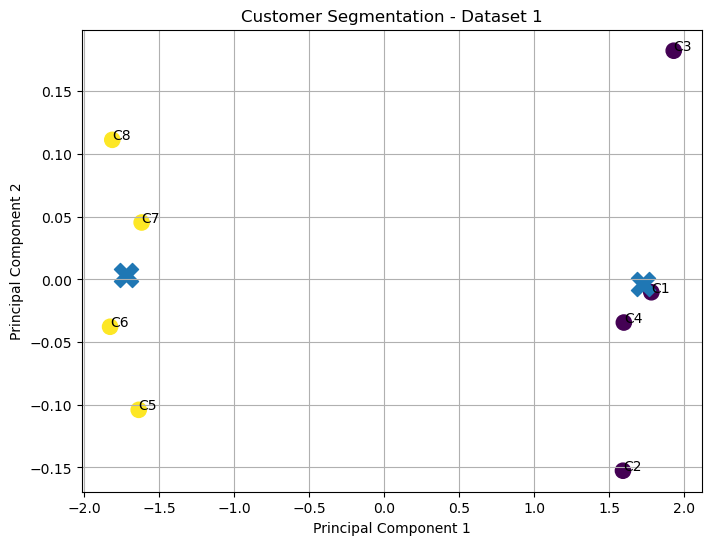

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# -----------------------------
# DATASET 1
# -----------------------------

data = {
    'Customer': ['C1','C2','C3','C4','C5','C6','C7','C8'],

    'Recency': [10, 12, 15, 18, 200, 220, 210, 230],

    'Frequency': [20, 18, 22, 19, 2, 1, 3, 2],

    'Monetary': [50000, 48000, 52000, 47000, 2000, 1500, 2500, 1800]
}

df = pd.DataFrame(data)

print("\nORIGINAL DATASET")
print(df)

# -----------------------------
# FEATURES
# -----------------------------

X = df[['Recency', 'Frequency', 'Monetary']]

# -----------------------------
# STANDARDIZATION
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------
# K-MEANS CLUSTERING
# -----------------------------

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

df['Cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------
# EVALUATION
# -----------------------------

score = silhouette_score(X_scaled, df['Cluster'])

print("\nSILHOUETTE SCORE:", round(score, 3))

print("\nFINAL CLUSTERS")
print(df)

# -----------------------------
# PCA FOR 2D VISUALIZATION
# -----------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# CENTROIDS IN PCA SPACE
centroids_pca = pca.transform(kmeans.cluster_centers_)

# -----------------------------
# PLOT
# -----------------------------

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df['Cluster'],
    s=120
)

# CUSTOMER LABELS
for i, customer in enumerate(df['Customer']):
    plt.text(X_pca[i,0], X_pca[i,1], customer)

# CENTROIDS
plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=300
)

plt.title("Customer Segmentation - Dataset 1")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# -----------------------------------
# LOAD DATASET
# -----------------------------------

df = pd.read_csv("transactions_train.csv")

# -----------------------------------
# TAKE SAMPLE FOR FAST EXECUTION
# -----------------------------------

df = df.sample(5000, random_state=42)

# -----------------------------------
# CONVERT DATE COLUMN
# -----------------------------------

df['t_dat'] = pd.to_datetime(df['t_dat'])

# -----------------------------------
# CREATE TOTAL SPENDING
# -----------------------------------

df['TotalPrice'] = df['price']

# -----------------------------------
# CREATE CUSTOMER FEATURES
# -----------------------------------

snapshot_date = df['t_dat'].max()

customer_features = df.groupby('customer_id').agg({

    't_dat': lambda x: (snapshot_date - x.max()).days,

    'article_id': 'count',

    'TotalPrice': 'sum'

}).reset_index()

# -----------------------------------
# RENAME COLUMNS
# -----------------------------------

customer_features.columns = [

    'CustomerID',

    'Recency',

    'Frequency',

    'Monetary'

]

print("\nCUSTOMER FEATURES")
print(customer_features.head())

# -----------------------------------
# SELECT FEATURES
# -----------------------------------

X = customer_features[['Recency', 'Frequency', 'Monetary']]

# -----------------------------------
# STANDARDIZATION
# -----------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -----------------------------------
# APPLY K-MEANS
# -----------------------------------

kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

customer_features['Cluster'] = kmeans.fit_predict(X_scaled)

# -----------------------------------
# EVALUATION
# -----------------------------------

sil_score = silhouette_score(

    X_scaled,

    customer_features['Cluster']

)

print("\nSILHOUETTE SCORE:", round(sil_score, 3))

# -----------------------------------
# PCA FOR VISUALIZATION
# -----------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# CENTROIDS
centroids_pca = pca.transform(kmeans.cluster_centers_)

# -----------------------------------
# VISUALIZATION
# -----------------------------------

plt.figure(figsize=(10,7))

plt.scatter(

    X_pca[:,0],

    X_pca[:,1],

    c=customer_features['Cluster'],

    s=20

)

# PLOT CENTROIDS
plt.scatter(

    centroids_pca[:,0],

    centroids_pca[:,1],

    marker='X',

    s=300

)

plt.title("H&M Customer Segmentation")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'transactions_train.csv'